# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Prima Surya Nusantara | 5054251036 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Disiapkan untuk tahap pemodelan dan evaluasi berikutnya
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="whitegrid")

In [48]:
DATA_PATH = "bankruptcy.csv"    # Ganti dengan lokasi file Anda
TARGET_COLUMN = "Bankrupt?"     # Ganti dengan nama kolom target

df = pd.read_csv(DATA_PATH)

print("Ukuran dataset:")
print(f"Jumlah baris  : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

print("\nLima baris pertama:")
display(df.head())

print("\nTipe data dan jumlah nilai non-null:")
df.info()

print("\nStatistik deskriptif:")
display(df.describe(include="all").T)

print("\nJumlah missing value per kolom:")
display(df.isna().sum().to_frame(name="jumlah_missing"))

Ukuran dataset:
Jumlah baris  : 6819
Jumlah kolom : 96

Lima baris pertama:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490



Tipe data dan jumlah nilai non-null:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0



Jumlah missing value per kolom:


,jumlah_missing
Bankrupt?,0
ROA(C) before interest and depreciation before interest,0
ROA(A) before interest and % after tax,0
ROA(B) before interest and depreciation after tax,0
Operating Gross Margin,0
...,...
Liability to Equity,0
Degree of Financial Leverage (DFL),0
Interest Coverage Ratio (Interest expense to EBIT),0
Net Income Flag,0


Distribusi kelas target:


,jumlah,persentase (%)
Bankrupt?,,
0,6599,96.77
1,220,3.23


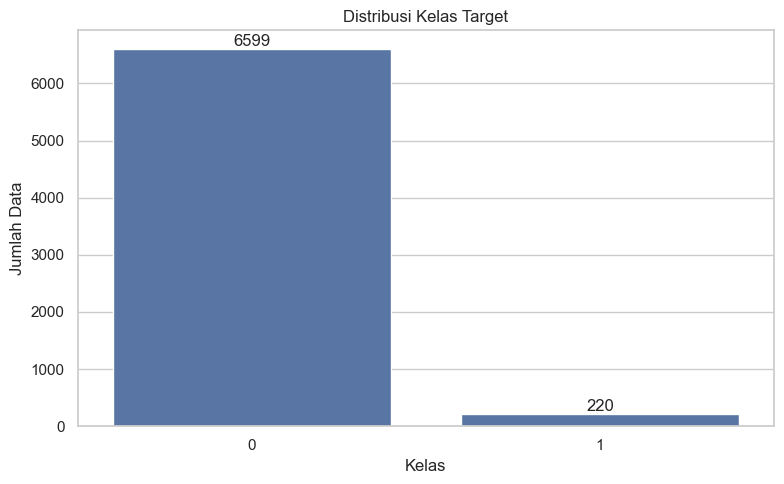

In [49]:
jumlah_kelas = df[TARGET_COLUMN].value_counts(dropna=False)
persentase_kelas = (
    df[TARGET_COLUMN]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

distribusi_target = pd.DataFrame({
    "jumlah": jumlah_kelas,
    "persentase (%)": persentase_kelas,
})

print("Distribusi kelas target:")
display(distribusi_target)

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x=TARGET_COLUMN,
    order=df[TARGET_COLUMN].value_counts().index,
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribusi Kelas Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

Fitur numerik: [' ROA(C) before interest and depreciation before interest', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Operating Gross Margin', ' Realized Sales Gross Margin', ' Operating Profit Rate', ' Pre-tax net Interest Rate', ' After-tax net Interest Rate', ' Non-industry income and expenditure/revenue', ' Continuous interest rate (after tax)', ' Operating Expense Rate', ' Research and development expense rate', ' Cash flow rate', ' Interest-bearing debt interest rate', ' Tax rate (A)', ' Net Value Per Share (B)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons', ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)', ' Operating Profit Per Share (Yuan ¥)', ' Per Share Net profit before tax (Yuan ¥)', ' Realized Sales Gross Profit Growth Rate', ' Operating Profit Growth Rate', ' After-tax Net Profit Growth Rate', ' Regular Net Profit Growth Rate', ' Continuous Net Profit Growt

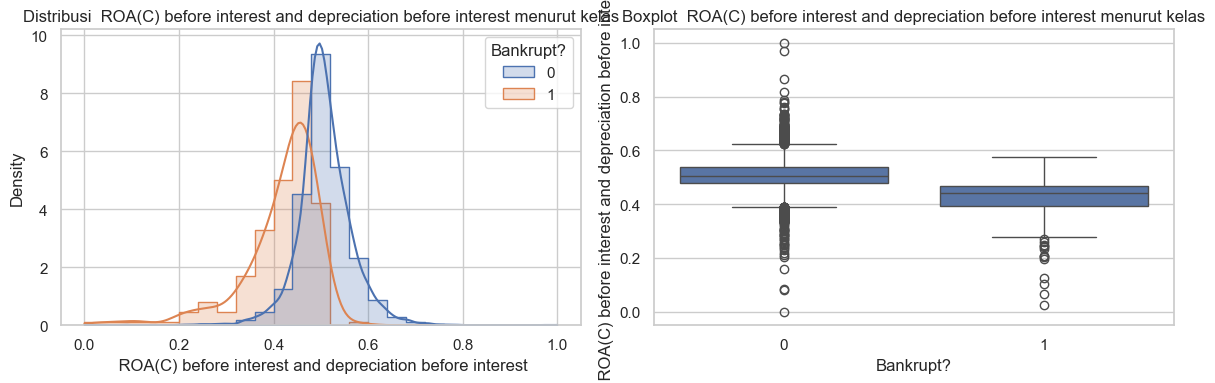

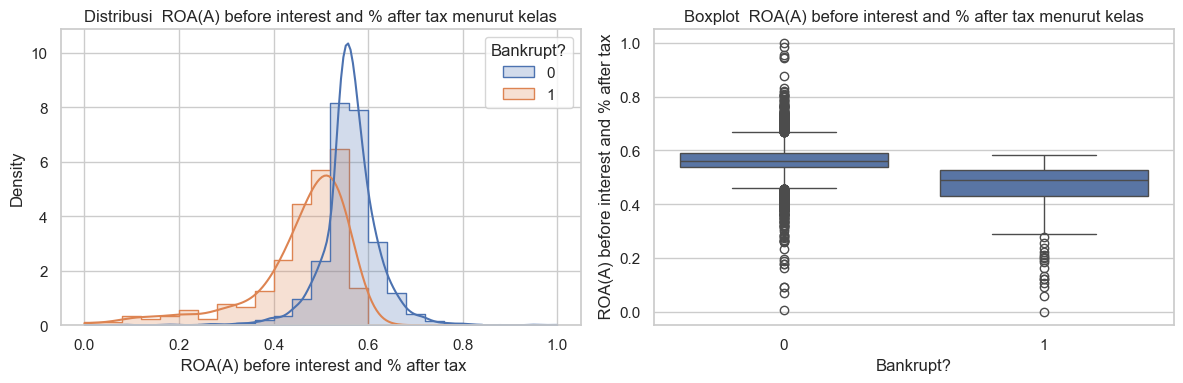

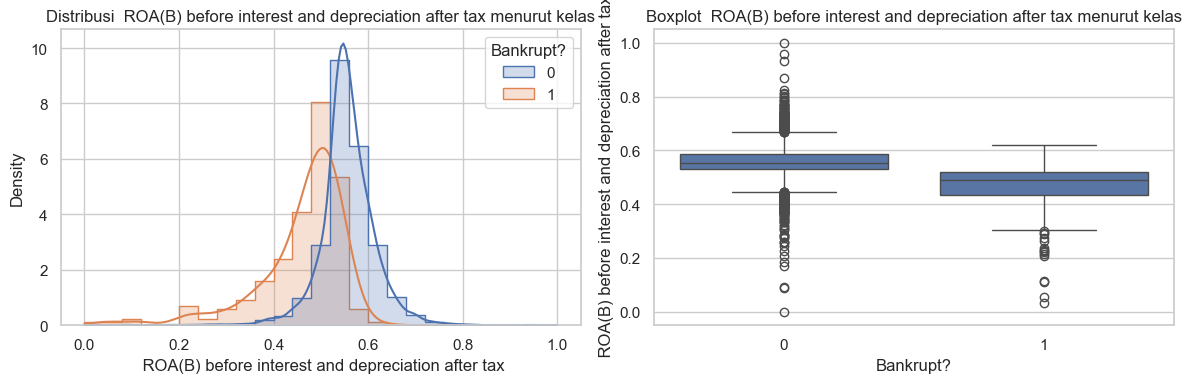

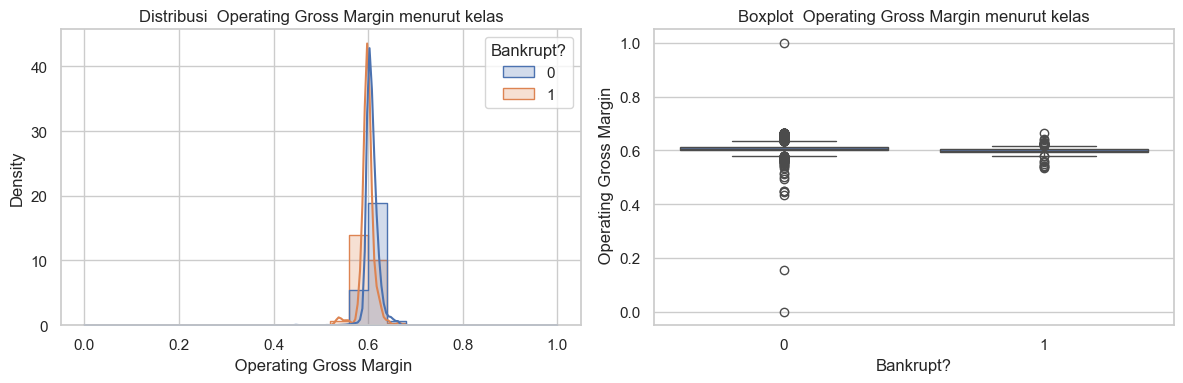

In [50]:
fitur_numerik = (
    df.drop(columns=TARGET_COLUMN)
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

fitur_kategorikal = (
    df.drop(columns=TARGET_COLUMN)
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("Fitur numerik:", fitur_numerik)
print("Fitur kategorikal:", fitur_kategorikal)

for fitur in fitur_numerik[:4]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(
        data=df,
        x=fitur,
        hue=TARGET_COLUMN,
        bins=25,
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[0],
    )
    axes[0].set_title(f"Distribusi {fitur} menurut kelas")

    sns.boxplot(
        data=df,
        x=TARGET_COLUMN,
        y=fitur,
        ax=axes[1],
    )
    axes[1].set_title(f"Boxplot {fitur} menurut kelas")

    plt.tight_layout()
    plt.show()

# Countplot fitur kategorikal
for fitur in fitur_kategorikal[:2]:
    kategori_teratas = df[fitur].value_counts().head(10).index
    data_plot = df[df[fitur].isin(kategori_teratas)]

    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=data_plot,
        x=fitur,
        hue=TARGET_COLUMN,
        order=kategori_teratas,
    )
    plt.title(f"Distribusi {fitur} menurut kelas")
    plt.xlabel(fitur)
    plt.ylabel("Jumlah Data")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [51]:
data_model = df.dropna(subset=[TARGET_COLUMN]).copy()

X = data_model.drop(columns=TARGET_COLUMN)
y = data_model[TARGET_COLUMN]

print("Jumlah missing value pada fitur sebelum preprocessing:")
display(X.isna().sum().to_frame(name="jumlah_missing"))

print(f"Jumlah baris yang digunakan: {len(data_model)}")
print(f"Jumlah baris tanpa target yang dikeluarkan: {len(df) - len(data_model)}")

Jumlah missing value pada fitur sebelum preprocessing:


,jumlah_missing
ROA(C) before interest and depreciation before interest,0
ROA(A) before interest and % after tax,0
ROA(B) before interest and depreciation after tax,0
Operating Gross Margin,0
Realized Sales Gross Margin,0
...,...
Liability to Equity,0
Degree of Financial Leverage (DFL),0
Interest Coverage Ratio (Interest expense to EBIT),0
Net Income Flag,0


Jumlah baris yang digunakan: 6819
Jumlah baris tanpa target yang dikeluarkan: 0


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)

print("\nProporsi kelas pada train set (%):")
display(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nProporsi kelas pada test set (%):")
display(y_test.value_counts(normalize=True).mul(100).round(2))

Ukuran X_train: (5455, 95)
Ukuran X_test : (1364, 95)

Proporsi kelas pada train set (%):


Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


Proporsi kelas pada test set (%):


Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

fitur_numerik = X.select_dtypes(include=np.number).columns.tolist()
fitur_kategorikal = X.select_dtypes(exclude=np.number).columns.tolist()

print("Fitur numerik:", fitur_numerik)
print("Fitur kategorikal:", fitur_kategorikal)

pipeline_numerik = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

pipeline_kategorikal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numerik", pipeline_numerik, fitur_numerik),
    ("kategorikal", pipeline_kategorikal, fitur_kategorikal),
])

# fit hanya pada train set; test set hanya menjalani transformasi.
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Ukuran train setelah preprocessing:", X_train_prepared.shape)
print("Ukuran test setelah preprocessing :", X_test_prepared.shape)

Fitur numerik: [' ROA(C) before interest and depreciation before interest', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Operating Gross Margin', ' Realized Sales Gross Margin', ' Operating Profit Rate', ' Pre-tax net Interest Rate', ' After-tax net Interest Rate', ' Non-industry income and expenditure/revenue', ' Continuous interest rate (after tax)', ' Operating Expense Rate', ' Research and development expense rate', ' Cash flow rate', ' Interest-bearing debt interest rate', ' Tax rate (A)', ' Net Value Per Share (B)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons', ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)', ' Operating Profit Per Share (Yuan ¥)', ' Per Share Net profit before tax (Yuan ¥)', ' Realized Sales Gross Profit Growth Rate', ' Operating Profit Growth Rate', ' After-tax Net Profit Growth Rate', ' Regular Net Profit Growth Rate', ' Continuous Net Profit Growt

**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [54]:
model_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

model_gini.fit(X_train_prepared, y_train)

DecisionTreeClassifier(random_state=42)

In [55]:
y_pred_gini = model_gini.predict(X_test_prepared)

print("Jumlah hasil prediksi:", len(y_pred_gini))
print("Distribusi label prediksi:")
print(pd.Series(y_pred_gini, name="prediksi").value_counts())

Jumlah hasil prediksi: 1364
Distribusi label prediksi:
prediksi
0    1320
1      44
Name: count, dtype: int64


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [56]:
model_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model_entropy.fit(X_train_prepared, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [57]:
y_pred_entropy = model_entropy.predict(X_test_prepared)

print("Jumlah hasil prediksi:", len(y_pred_entropy))
print("Distribusi label prediksi:")
print(pd.Series(y_pred_entropy, name="prediksi").value_counts())

Jumlah hasil prediksi: 1364
Distribusi label prediksi:
prediksi
0    1325
1      39
Name: count, dtype: int64


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [58]:
daftar_max_depth = [1, 2, 3, 5, 10, None]
criterion_terpilih = "gini"

hasil_kedalaman = []

for depth in daftar_max_depth:
    model = DecisionTreeClassifier(
        criterion=criterion_terpilih,
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train_prepared, y_train)

    hasil_kedalaman.append({
        "max_depth": depth,
        "akurasi_train": accuracy_score(
            y_train, model.predict(X_train_prepared)
        ),
        "akurasi_test": accuracy_score(
            y_test, model.predict(X_test_prepared)
        ),
        "kedalaman_aktual": model.get_depth()
    })

df_kedalaman = pd.DataFrame(hasil_kedalaman)
display(df_kedalaman)

,max_depth,akurasi_train,akurasi_test,kedalaman_aktual
0,1.0,0.967736,0.967742,1
1,2.0,0.969936,0.969941,2
2,3.0,0.972319,0.969941,3
3,5.0,0.977452,0.968475,5
4,10.0,0.994684,0.960411,10
5,NaN,1.000000,0.960411,19


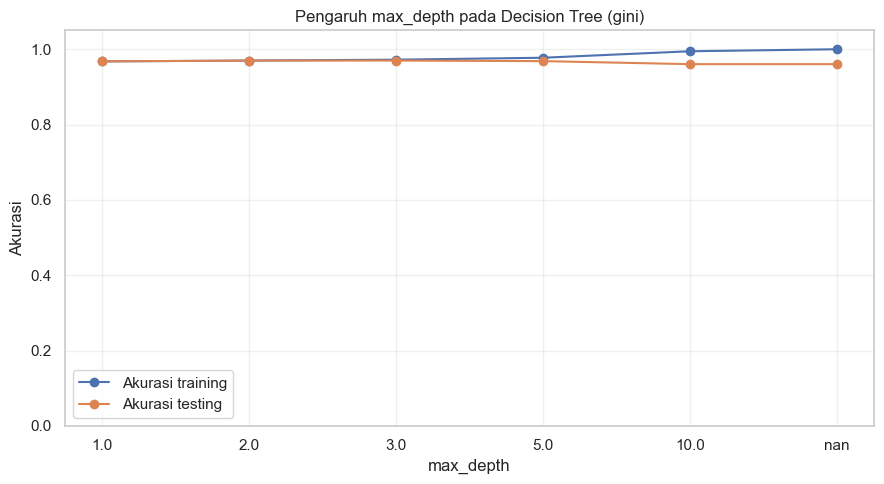

In [59]:
posisi = range(len(df_kedalaman))
label_depth = df_kedalaman["max_depth"].astype(str)

plt.figure(figsize=(9, 5))
plt.plot(
    posisi, df_kedalaman["akurasi_train"],
    marker="o", label="Akurasi training"
)
plt.plot(
    posisi, df_kedalaman["akurasi_test"],
    marker="o", label="Akurasi testing"
)

plt.xticks(posisi, label_depth)
plt.xlabel("max_depth")
plt.ylabel("Akurasi")
plt.title(f"Pengaruh max_depth pada Decision Tree ({criterion_terpilih})")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

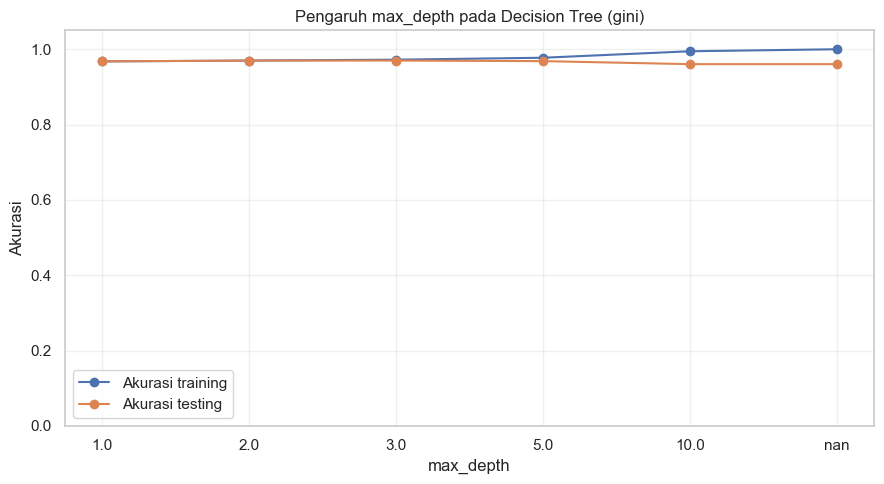

In [60]:
posisi = range(len(df_kedalaman))
label_depth = df_kedalaman["max_depth"].astype(str)

plt.figure(figsize=(9, 5))
plt.plot(
    posisi, df_kedalaman["akurasi_train"],
    marker="o", label="Akurasi training"
)
plt.plot(
    posisi, df_kedalaman["akurasi_test"],
    marker="o", label="Akurasi testing"
)

plt.xticks(posisi, label_depth)
plt.xlabel("max_depth")
plt.ylabel("Akurasi")
plt.title(f"Pengaruh max_depth pada Decision Tree ({criterion_terpilih})")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [61]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

model_dan_prediksi = {
    "Gini": (model_gini, y_pred_gini),
    "Entropy": (model_entropy, y_pred_entropy),
}

hasil_evaluasi = []

for nama, (model, prediksi) in model_dan_prediksi.items():
    hasil_evaluasi.append({
        "Model": nama,
        "Accuracy": accuracy_score(y_test, prediksi),
        "Precision kelas 1": precision_score(
            y_test, prediksi, pos_label=1, zero_division=0
        ),
        "Recall kelas 1": recall_score(
            y_test, prediksi, pos_label=1, zero_division=0
        ),
        "F1-Score kelas 1": f1_score(
            y_test, prediksi, pos_label=1, zero_division=0
        ),
    })

df_evaluasi = pd.DataFrame(hasil_evaluasi)
display(df_evaluasi.round(4))

,Model,Accuracy,Precision kelas 1,Recall kelas 1,F1-Score kelas 1
0,Gini,0.9604,0.3864,0.3864,0.3864
1,Entropy,0.9641,0.4359,0.3864,0.4096


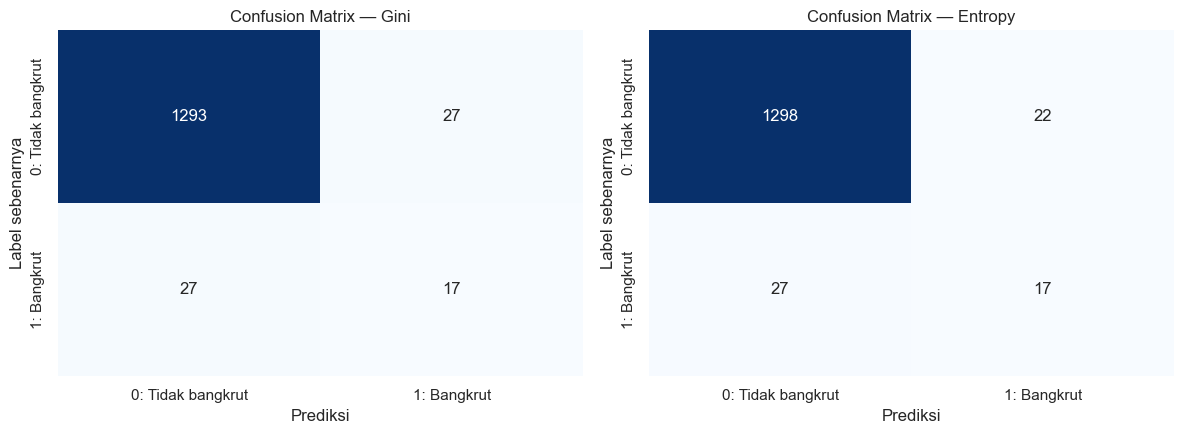

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (nama, (_, prediksi)) in zip(
    axes, model_dan_prediksi.items()
):
    cm = confusion_matrix(y_test, prediksi, labels=[0, 1])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["0: Tidak bangkrut", "1: Bangkrut"],
        yticklabels=["0: Tidak bangkrut", "1: Bangkrut"],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix — {nama}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Label sebenarnya")

plt.tight_layout()
plt.show()

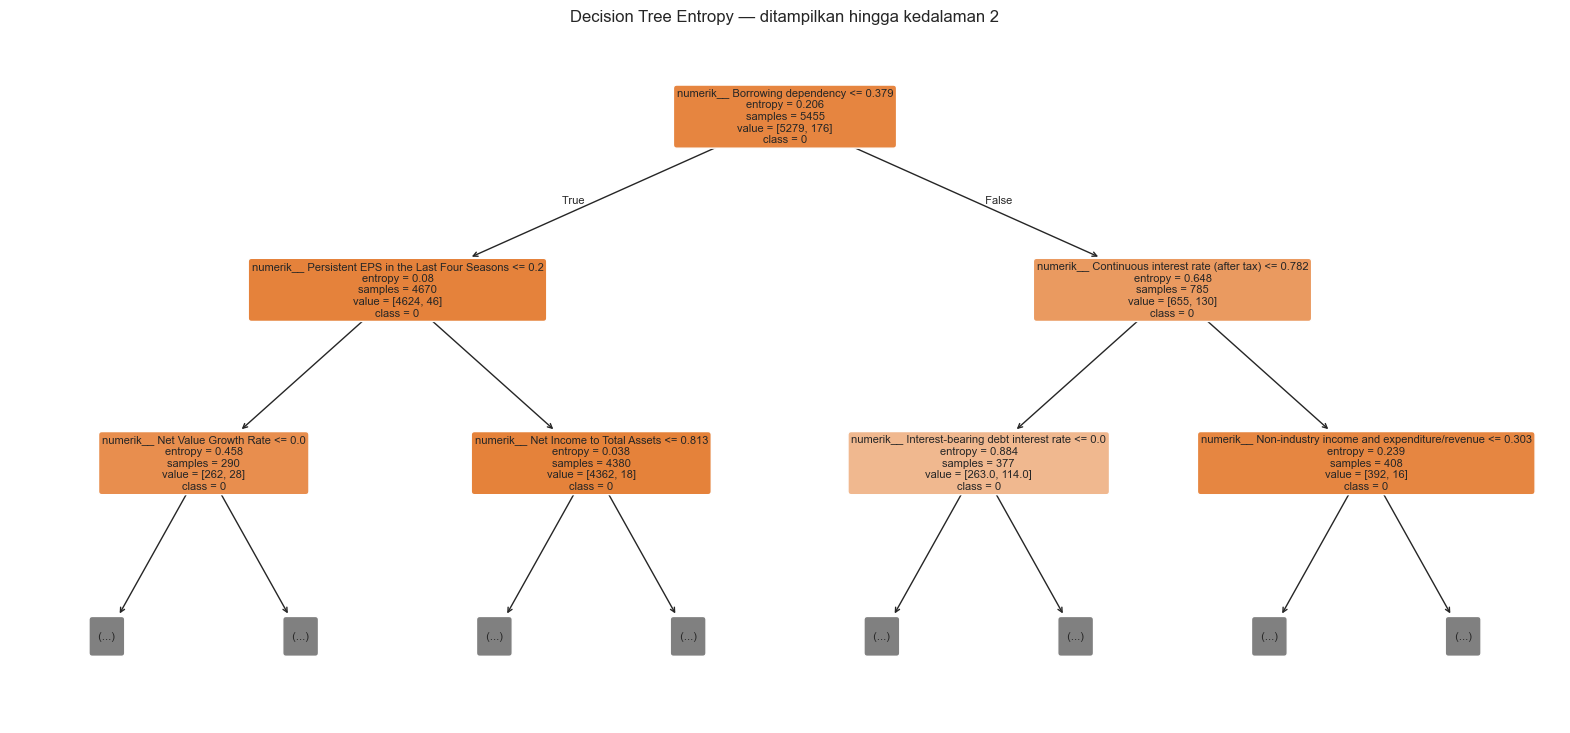

Model terpilih untuk visualisasi: Entropy
F1-Score kelas 1: 0.4096


In [ ]:
from sklearn.tree import plot_tree

baris_terbaik = (
    df_evaluasi
    .sort_values(
        ["F1-Score kelas 1", "Recall kelas 1"],
        ascending=False
    )
    .iloc[0]
)

nama_terbaik = baris_terbaik["Model"]
model_terbaik = model_dan_prediksi[nama_terbaik][0]

nama_fitur = preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 9))
plot_tree(
    model_terbaik,
    feature_names=nama_fitur,
    class_names=[str(kelas) for kelas in model_terbaik.classes_],
    max_depth=2,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title(f"Decision Tree {nama_terbaik} — ditampilkan hingga kedalaman 2")
plt.show()

print("Model terpilih untuk visualisasi:", nama_terbaik)
print("F1-Score kelas 1:", round(baris_terbaik["F1-Score kelas 1"], 4))

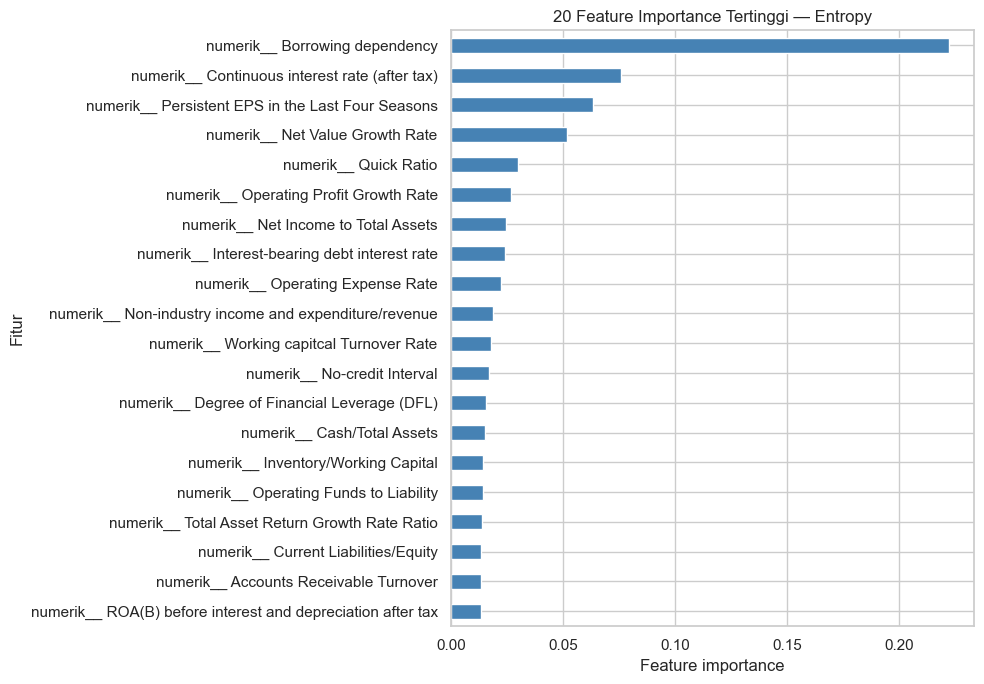

,importance
numerik__ Borrowing dependency,0.222147
numerik__ Continuous interest rate (after tax),0.075791
numerik__ Persistent EPS in the Last Four Seasons,0.063519
numerik__ Net Value Growth Rate,0.051659
numerik__ Quick Ratio,0.029765
numerik__ Operating Profit Growth Rate,0.026979
numerik__ Net Income to Total Assets,0.024663
numerik__ Interest-bearing debt interest rate,0.024218
numerik__ Operating Expense Rate,0.022477
numerik__ Non-industry income and expenditure/revenue,0.018859


In [64]:
importance = (
    pd.Series(
        model_terbaik.feature_importances_,
        index=nama_fitur,
        name="importance"
    )
    .sort_values(ascending=False)
)

# Tampilkan maksimal 20 fitur teratas agar grafik tetap terbaca
importance_teratas = importance.head(20).sort_values()

plt.figure(figsize=(10, max(5, len(importance_teratas) * 0.35)))
importance_teratas.plot.barh(color="steelblue")
plt.xlabel("Feature importance")
plt.ylabel("Fitur")
plt.title(f"20 Feature Importance Tertinggi — {nama_terbaik}")
plt.tight_layout()
plt.show()

display(importance.head(20).to_frame())

# 5. Analisis

## 5.1. Perbandingan kriteria Gini dan Entropy

| Model   |    Akurasi | Precision kelas bangkrut (1) | Recall kelas bangkrut (1) | F1-score kelas bangkrut (1) |
| ------- | ---------: | ---------------------------: | ------------------------: | --------------------------: |
| Gini    |     0,9604 |                       0,3864 |                    0,3864 |                      0,3864 |
| Entropy | **0,9641** |                   **0,4359** |                    0,3864 |                  **0,4096** |

Pada pengujian ini, Entropy menghasilkan performa sedikit lebih baik daripada Gini, terutama pada precision dan F1-score kelas bangkrut. Entropy benar memprediksi 17 dari 44 perusahaan yang bangkrut, sama seperti Gini. Perbedaannya ada pada perusahaan yang sebenarnya tidak bangkrut tetapi diprediksi bangkrut: 22 kasus pada Entropy, dibandingkan 27 kasus pada Gini. Dengan demikian, Entropy mengurangi lima false positive tanpa menambah jumlah kasus bangkrut yang berhasil ditemukan.

Perbedaan tersebut dapat terjadi karena Gini dan Entropy menggunakan cara berbeda untuk menilai kualitas pemisahan pada setiap simpul pohon. Akibatnya, fitur atau batas pemisahan yang dipilih dapat berbeda. Selisih akurasi kedua model hanya 0,0037, atau 0,37 poin persentase; hasil satu kali pembagian data ini belum cukup untuk menyatakan bahwa perbedaannya signifikan secara statistik.

Ada hal penting pada dataset ini: test set memuat 1.320 kelas 0 dan 44 kelas 1. Model yang selalu memprediksi kelas 0 akan memperoleh akurasi 1.320/1.364 = 0,9677, lebih tinggi daripada akurasi kedua pohon tanpa batas kedalaman. Akan tetapi, model seperti itu tidak menemukan satu pun kasus bangkrut. Karena itu, akurasi perlu dibaca bersama recall dan F1-score kelas 1. Pada kedua pohon, recall 0,3864 berarti hanya 17 dari 44 kasus bangkrut yang ditemukan; 27 kasus bangkrut masih terlewat.

## 5.2. Pengaruh `max_depth` dan gejala overfitting
Eksperimen kedalaman berikut menggunakan kriteria Gini.

| `max_depth` | Akurasi train | Akurasi test | Selisih train–test |
| ----------- | ------------: | -----------: | -----------------: |
| 1           |        0,9677 |       0,9677 |             0,0000 |
| 2           |        0,9699 |       0,9699 |             0,0000 |
| 3           |        0,9723 |       0,9699 |             0,0024 |
| 5           |        0,9775 |       0,9685 |             0,0090 |
| 10          |        0,9947 |       0,9604 |             0,0343 |
| Tanpa batas |        1,0000 |       0,9604 |             0,0396 |

Tanda awal overfitting terlihat pada `max_depth=5`: akurasi train masih naik, sementara akurasi test mulai turun dari 0,9699 menjadi 0,9685. Gejalanya menjadi jelas pada `max_depth=10`, ketika akurasi train mencapai 0,9947 tetapi akurasi test turun menjadi 0,9604. Tanpa batas kedalaman, pohon tumbuh hingga kedalaman aktual 19 dan mengklasifikasikan seluruh data train dengan benar (akurasi 1,0000), tetapi akurasi test tetap 0,9604. Pola ini menunjukkan bahwa penambahan kedalaman membuat model semakin sesuai dengan data latih tanpa meningkatkan kemampuannya pada data uji.

Akurasi test tertinggi pada tabel diperoleh pada `max_depth=2` dan `max_depth=3`, keduanya 0,9699. Namun, belum bisa disimpulkan bahwa salah satunya model terbaik untuk mendeteksi kebangkrutan, karena precision, recall, dan F1-score kelas 1 pada tiap kedalaman belum dihitung. Pohon yang tampak baik dari akurasi bisa saja terlalu sering memilih kelas mayoritas.

## 5.3. Feature importance model Entropy
Model Entropy yang divisualisasikan menempatkan Borrowing dependency sebagai fitur dengan importance tertinggi, yaitu 0,2221. Nilainya jauh di atas fitur kedua, Continuous interest rate (after tax) (0,0758), dan fitur ketiga, Persistent EPS in the Last Four Seasons (0,0635). Fitur berikutnya adalah Net Value Growth Rate (0,0517), disusul Quick Ratio (0,0298).

Artinya, Borrowing dependency memberikan kontribusi terbesar terhadap pengurangan impurity pada pohon Entropy yang dilatih. Sekitar 22,21% dari total importance model. Nilai ini tidak menunjukkan bahwa kenaikan Borrowing dependency menyebabkan kebangkrutan, dan tidak dengan sendirinya menunjukkan arah pengaruhnya. Untuk mengetahui batas nilai serta arah keputusan yang digunakan model, periksa simpul yang melibatkan fitur tersebut pada visualisasi pohon.

# 6. Kesimpulan dan Saran

## 6.1. Kesimpulan:
Pada eksperimen Gini versus Entropy tanpa batas kedalaman, Entropy unggul tipis karena menghasilkan lima false positive lebih sedikit, tetapi keduanya hanya menemukan 17 dari 44 kasus bangkrut. Pembatasan max_depth membantu mengendalikan overfitting; penurunan akurasi test mulai tampak pada kedalaman 5 dan semakin jelas pada kedalaman 10. Fitur paling berpengaruh pada model Entropy adalah Borrowing dependency. Mengingat ketimpangan kelas yang besar, langkah analisis berikutnya yang paling relevan adalah membandingkan recall dan F1-score kelas bangkrut pada setiap nilai max_depth, sebelum memilih kedalaman model.

## 6.2. Saran:
Berdasarkan hasil eksperimen, jangan memilih model hanya dari akurasi, karena kelas bangkrut hanya mencakup sekitar 3,23% data. Meskipun Entropy sedikit lebih baik daripada Gini, kedua model masih melewatkan 27 dari 44 perusahaan yang bangkrut pada test set. Evaluasi selanjutnya perlu memprioritaskan recall dan F1-score kelas bangkrut, serta melihat jumlah false negative pada confusion matrix.

Untuk mengurangi overfitting, uji lebih lanjut max_depth di sekitar 2–5. Kedalaman 2 dan 3 menghasilkan akurasi test tertinggi dalam percobaan ini, tetapi nilai terbaik untuk mendeteksi kebangkrutan belum dapat dipastikan sebelum recall dan F1-score kelas 1 dihitung pada setiap kedalaman. Pilih kedalaman menggunakan validasi pada train set, kemudian gunakan test set untuk evaluasi akhir.

Sebagai eksperimen lanjutan, bandingkan model biasa dengan class_weight="balanced" untuk melihat apakah lebih banyak kasus bangkrut dapat ditemukan. Perhatikan kemungkinan kenaikan false positive saat menilai hasilnya. Jika mencoba penyeimbangan data melalui oversampling, terapkan hanya pada data latih agar tidak terjadi data leakage.